In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score






In [2]:
# Loading Dataset
data = pd.read_csv('Students.csv')


In [3]:
#Displaying firts five rows
data.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [4]:
# How many rows and columns in dataset
data.shape

(1000, 16)

In [5]:
# Checking dataset information
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality               1000 non-null   str    
 13  

In [7]:
# checking is their any duplicate value
data.duplicated().sum()

np.int64(0)

In [9]:
# Selecting all numeric columns
numeric_col = data.select_dtypes(include=[np.number])
print(numeric_col.columns.tolist())

['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']


In [11]:
# Fetaure: X = all numeric values except exam_score
#        : y = exam_score [target_column]
X = numeric_col.drop('exam_score', axis=1)
y = data.exam_score

In [13]:
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [14]:
# Create LinearRegression = lr
lr = LinearRegression()

In [15]:
# Training the model
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.05, 9.53,-2.7 ,..., 1.99, 1.32, 1.95]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','study_hours_per_day','social_media_hours',...,'sleep_hours', 'exercise_frequency','mental_health_rating']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.906
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [16]:
# Predict exam scores
y_pred = lr.predict(X_test)

In [18]:
# MAE (Mean Absolute Error) - average error
mae = mean_absolute_error(y_test,y_pred)
print('MAE: ',mae)

MAE:  4.130186149064832


In [19]:
# MSE (Mean Squared Error) - average error after squaring
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 25.9210099090126


In [20]:
# RMSE (Root Mean Squared Error) - MSE square root
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 5.091268006009171


In [22]:
# R2 Score - model explaining variance between 0 and 1
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.8989154884786842


In [23]:
# Calulate overall evaluation metrics
print("\n Model Evaluation ")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)


 Model Evaluation 
MAE: 4.130186149064832
MSE: 25.9210099090126
RMSE: 5.091268006009171
R² Score: 0.8989154884786842


In [24]:
# Creating Dataframe to compare actula and predicted scores
results = pd.DataFrame({'Actual Exam Score': y_test.values,
                        'Predicted Exam score': y_pred
                       })
print('\n   Prediction Results')
results.head(10)


   Prediction Results


,Actual Exam Score,Predicted Exam score
0,64.2,66.052043
1,72.7,74.481327
2,79.0,78.104848
3,79.5,74.380344
4,58.2,61.424546
5,53.4,54.834888
6,70.8,75.917712
7,62.5,55.428013
8,36.8,41.610086
9,67.6,72.816125


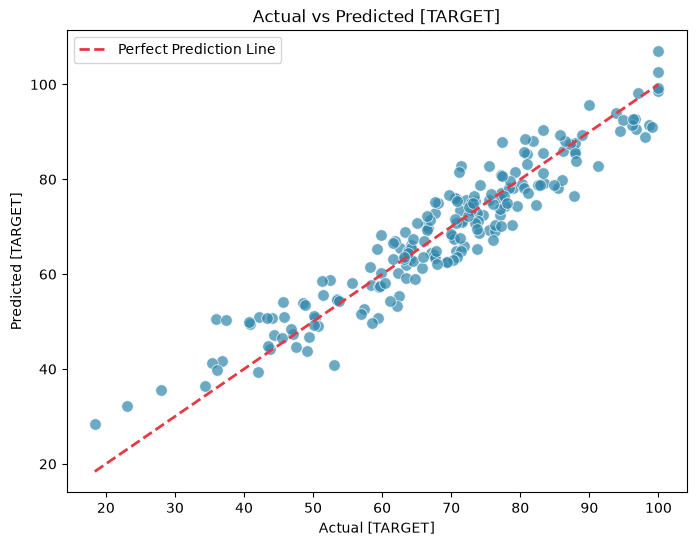

In [ ]:

# Plotting actual vs. predicted values to evaluate the model's prediction performance
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='#2E86AB', edgecolor='white', s=70)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='#E63946', linestyle='--', linewidth=2, label='Perfect Prediction Line')
plt.xlabel('Actual [TARGET]')
plt.ylabel('Predicted [TARGET]')
plt.title('Actual vs Predicted [TARGET]')
plt.legend()
plt.show()